# Predicting Diabetes Diagnosis with Support Vector Machines
### DATA 5322 – Practical Homework 2 | NHIS 2022

---

**Research Question:** Can we predict whether a U.S. adult has ever been diagnosed with diabetes using demographic, lifestyle, and dietary data from the 2022 National Health Interview Survey?

**Why this target?**
- Clinically significant: diabetes affects ~37 million Americans [1]
- Binary outcome (`DIABETICEV`): diagnosed (yes/no) after filtering refused/unknown
- ~10% prevalence  -  modest class imbalance, manageable with `class_weight='balanced'`
- Strong theoretical feature links: BMI, age, physical activity, diet all have documented associations with diabetes risk [2]

**Methods:** Support Vector Classifier (linear, RBF, and polynomial kernels) with systematic hyperparameter tuning via `GridSearchCV`.

## Motivation and Approach

This project explores whether demographic and lifestyle variables alone can be used to predict diabetes diagnosis. I chose this problem because it represents a realistic scenario where clinical data may not be available, and early screening must rely on survey-based inputs. I use Support Vector Machines (SVM) to evaluate both linear and non-linear decision boundaries in this context.

## 1. Imports & Configuration

In [1]:
import time
import warnings

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Scikit-learn: model, tuning, evaluation
from sklearn.svm import SVC
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score, GridSearchCV, ValidationCurveDisplay
)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    classification_report, ConfusionMatrixDisplay,
    roc_auc_score, RocCurveDisplay
)
from sklearn.pipeline import Pipeline
from sklearn.inspection import DecisionBoundaryDisplay

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

RANDOM_STATE = 42          # fixed seed for reproducibility
FIGDIR = 'figures/'        # directory for poster-ready figure exports

import os
os.makedirs(FIGDIR, exist_ok=True)

## 2. Data Loading

In [2]:
raw = pd.read_csv('nhis_2022.csv')
print(f'Raw dataset: {raw.shape[0]:,} rows × {raw.shape[1]} columns')
print('\nColumn names:')
print(list(raw.columns))
raw.head(3)

Raw dataset: 35,115 rows × 48 columns

Column names:
['YEAR', 'SERIAL', 'STRATA', 'PSU', 'NHISHID', 'REGION', 'PERNUM', 'NHISPID', 'HHX', 'SAMPWEIGHT', 'ASTATFLG', 'CSTATFLG', 'AGE', 'SEX', 'MARSTCUR', 'EDUC', 'HOURSWRK', 'POVERTY', 'HEIGHT', 'WEIGHT', 'BMICALC', 'HINOTCOVE', 'CANCEREV', 'CHEARTDIEV', 'DIABETICEV', 'HEARTATTEV', 'STROKEV', 'ALCANYNO', 'ALCDAYSYR', 'CIGDAYMO', 'MOD10DMIN', 'VIG10DMIN', 'FRUTNO', 'VEGENO', 'JUICEMNO', 'SALADSNO', 'BEANNO', 'SALSAMNO', 'TOMSAUCEMNO', 'SODAPNO', 'FRIESPNO', 'SPORDRMNO', 'FRTDRINKMNO', 'COFETEAMNO', 'POTATONO', 'PIZZANO', 'HRSLEEP', 'CVDSHT']


,YEAR,SERIAL,STRATA,PSU,NHISHID,REGION,PERNUM,NHISPID,HHX,SAMPWEIGHT,ASTATFLG,CSTATFLG,AGE,SEX,MARSTCUR,EDUC,HOURSWRK,POVERTY,HEIGHT,WEIGHT,BMICALC,HINOTCOVE,CANCEREV,CHEARTDIEV,DIABETICEV,HEARTATTEV,STROKEV,ALCANYNO,ALCDAYSYR,CIGDAYMO,MOD10DMIN,VIG10DMIN,FRUTNO,VEGENO,JUICEMNO,SALADSNO,BEANNO,SALSAMNO,TOMSAUCEMNO,SODAPNO,FRIESPNO,SPORDRMNO,FRTDRINKMNO,COFETEAMNO,POTATONO,PIZZANO,HRSLEEP,CVDSHT
0,2022,1,143,16,0002022H000001,4,1,0002022H00000110,H000001,8018.0,1,0,61,1,1,201,45,34,69,260,38.4,1,1,1,1,1,1,2,104,96,0,0,5,15,0,10,5,5,2,0,110,3,0,0,3,2,8,1
1,2022,2,106,53,0002022H000003,3,1,0002022H00000310,H000003,10117.0,1,0,43,1,1,301,45,37,70,190,27.3,1,1,1,1,1,1,1,52,96,20,0,1,1,1,1,1,1,1,0,1,0,0,1,1,1,6,2
2,2022,2,106,53,0002022H000003,3,2,0002022H00000320,H000003,7933.0,0,1,12,2,0,0,0,37,60,96,18.7,1,0,0,1,0,0,996,996,96,0,0,996,996,996,996,996,996,996,996,996,996,996,996,996,996,0,2


## 3. Column Selection

We select 13 predictors with direct theoretical links to diabetes risk [2,3]. Administrative/survey-design columns (serial numbers, strata, weights) are excluded - they encode sampling design, not health characteristics.

| Column | Human-Readable Name | Type | Diabetes Rationale |
|---|---|---|---|
| `AGE` | Age (years) | Continuous | Risk increases sharply after 45; adults 45–64 receive the most new diagnoses [2] |
| `SEX` | Sex (Male/Female) | Binary nominal | Men have higher prevalence (≈18%) than women (≈14%) [1] |
| `EDUC` | Education level | Ordinal | Inverse socioeconomic gradient: lower education associated with higher risk [3] |
| `POVERTY` | Poverty tier (FPL) | Ordinal | Lower income linked to higher diabetes prevalence [3] |
| `BMICALC` | BMI | Continuous | Strongest modifiable risk factor; obesity drives insulin resistance [2] |
| `HRSLEEP` | Sleep hours/night | Continuous | U-shaped risk: optimal sleep 7–8 hrs; short or long sleep raises T2D risk [4] |
| `MOD10DMIN` | Moderate activity (min/day) | Continuous | Physical activity improves insulin sensitivity [2] |
| `VIG10DMIN` | Vigorous activity (min/day) | Continuous | Same pathway, generally stronger effect |
| `CIGDAYMO` | Cigarettes/day | Continuous | Smokers are 30–40% more likely to develop T2D than non-smokers [5] |
| `ALCDAYSYR` | Alcohol days/year | Continuous | U-shaped relationship: moderate consumption may modestly reduce risk; heavy use raises risk above abstainers [6] |
| `FRUTNO` | Fruit frequency (times/year) | Continuous | Diet quality marker; higher intake generally protective |
| `VEGENO` | Vegetable frequency (times/year) | Continuous | Diet quality marker |
| `SODAPNO` | Soda frequency (times/year) | Continuous | Sugar-sweetened beverages raise T2D risk 13–18% per daily serving [7] |

#### Why add these features

I selected features across demographic, behavioral, and dietary categories to capture multiple dimensions of diabetes risk. Variables such as BMI and age are well-established predictors, while lifestyle variables (e.g., activity level, smoking, diet) allow the model to capture modifiable risk factors. This selection balances interpretability with predictive potential.

In [3]:
TARGET = 'DIABETICEV'

FEATURES = [
    'AGE', 'SEX', 'EDUC', 'POVERTY',
    'BMICALC',
    'HRSLEEP', 'MOD10DMIN', 'VIG10DMIN',
    'CIGDAYMO', 'ALCDAYSYR',
    'FRUTNO', 'VEGENO', 'SODAPNO',
]

# Human-readable labels for all plots
FEATURE_LABELS = {
    'AGE':       'Age (years)',
    'SEX':       'Sex (0=Male, 1=Female)',
    'EDUC':      'Education Level',
    'POVERTY':   'Poverty Tier (FPL)',
    'BMICALC':   'BMI',
    'HRSLEEP':   'Sleep (hours/night)',
    'MOD10DMIN': 'Moderate Activity (min/day)',
    'VIG10DMIN': 'Vigorous Activity (min/day)',
    'CIGDAYMO':  'Cigarettes/day',
    'ALCDAYSYR': 'Alcohol Days/year',
    'FRUTNO':    'Fruit Consumption (times/year)',
    'VEGENO':    'Vegetable Consumption (times/year)',
    'SODAPNO':   'Soda Consumption (times/year)',
}

selected = raw[['ASTATFLG'] + FEATURES + [TARGET]].copy()
print(f'Selected: {len(FEATURES)} features + 1 target + 1 filter flag = {selected.shape[1]} columns')

Selected: 13 features + 1 target + 1 filter flag = 15 columns


## 4. Data Cleaning

### Why data cleaning matters
Before modeling, I cleaned the dataset to remove special NHIS codes (e.g., 996, 96) that do not represent true values. These codes correspond to non-responses or inapplicable entries and would otherwise distort the model. I also restricted the dataset to adults, since diabetes prevalence and associated risk factors differ significantly between adults and children.

### 4.1 Filter to Adult Sample Persons

`ASTATFLG == 1` marks the single randomly-selected adult per household who completed the adult supplement. Children and non-sample household members (flag = 0) did not answer the health-condition questions and must be excluded.

In [4]:
df = selected[selected['ASTATFLG'] == 1].drop(columns='ASTATFLG').copy()
print(f'Adult sample: {len(df):,} rows')

Adult sample: 27,651 rows


### 4.2 Target: DIABETICEV

NHIS coding: **1 = No**, **2 = Yes**, 7 = Refused, 9 = Don't know.
We keep only valid responses and remap to a standard binary label: **0 = No diabetes, 1 = Diabetes**.

In [5]:
print('DIABETICEV value counts (raw):', df[TARGET].value_counts().to_dict())

df = df[df[TARGET].isin([1, 2])].copy()
df[TARGET] = (df[TARGET] == 2).astype(int)  # 0=no, 1=yes

print(f'\nValid rows: {len(df):,}')
print(f'Diabetes prevalence: {df[TARGET].mean():.1%}')

DIABETICEV value counts (raw): {1: 24673, 2: 2946, 7: 23, 9: 9}

Valid rows: 27,619
Diabetes prevalence: 10.7%


### 4.3 Per-Column Missingness / Special-Code Analysis

NHIS encodes non-response and inapplicability with numeric sentinel values:

| Code | Meaning | Our strategy |
|---|---|---|
| 96 / 996 | Not in universe (NIU)  -  question did not apply | Recode to 0 where meaningful |
| 997 | Refused | Drop row |
| 998 | Not ascertained | Drop row |
| 999 | Don't know | Drop row |
| 996 (BMICALC) | Not ascertained | Drop row |

We audit each column before removing any rows so we can report impact transparently.

In [6]:
# Recode NIU values to 0 BEFORE the missingness audit
df['CIGDAYMO']  = df['CIGDAYMO'].replace(96, 0)   # 96 = never smoked → 0 cigarettes
df['ALCDAYSYR'] = df['ALCDAYSYR'].replace(996, 0)  # 996 = non-drinker → 0 days

# Sentinel codes that indicate true missing / non-response
INVALID_CODES = {
    'AGE':       [997, 999],
    'SEX':       [7, 9],
    'EDUC':      [997, 999],
    'BMICALC':   [996],
    'HRSLEEP':   [97, 98, 99],
    'MOD10DMIN': [996, 997, 998, 999],
    'VIG10DMIN': [996, 997, 998, 999],
    'CIGDAYMO':  [97, 98, 99],
    'ALCDAYSYR': [997, 998, 999],
    'FRUTNO':    [997, 998, 999],
    'VEGENO':    [997, 998, 999],
    'SODAPNO':   [997, 998, 999],
}

# Audit: count invalid rows per column BEFORE dropping
n_total = len(df)
audit = []
for col, codes in INVALID_CODES.items():
    n_invalid = df[col].isin(codes).sum()
    audit.append({
        'Feature': FEATURE_LABELS[col],
        'Column': col,
        'Invalid rows': n_invalid,
        '% of adults': round(100 * n_invalid / n_total, 2),
        'Sentinel codes': str(codes),
    })

audit_df = pd.DataFrame(audit).set_index('Feature')
print(f'Total adult rows before cleaning: {n_total:,}\n')
print(audit_df[['Invalid rows', '% of adults', 'Sentinel codes']].to_string())

Total adult rows before cleaning: 27,619

                                    Invalid rows  % of adults        Sentinel codes
Feature                                                                            
Age (years)                                   61         0.22            [997, 999]
Sex (0=Male, 1=Female)                         3         0.01                [7, 9]
Education Level                              147         0.53            [997, 999]
BMI                                         2381         8.62                 [996]
Sleep (hours/night)                          966         3.50          [97, 98, 99]
Moderate Activity (min/day)                   88         0.32  [996, 997, 998, 999]
Vigorous Activity (min/day)                   45         0.16  [996, 997, 998, 999]
Cigarettes/day                                20         0.07          [97, 98, 99]
Alcohol Days/year                            166         0.60       [997, 998, 999]
Fruit Consumption (times/year)    

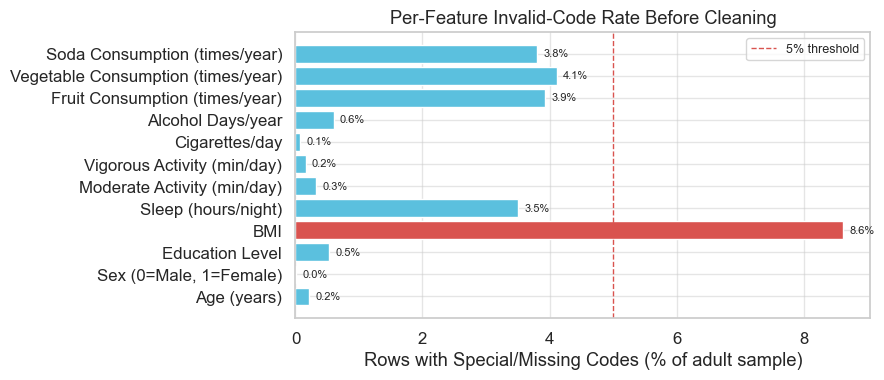

NOTE: BMICALC has the highest removal rate (~8.5%)  -  primarily unweighed/non-response.


In [7]:
# Visualise per-column invalid rates
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#d9534f' if p > 5 else '#5bc0de' for p in audit_df['% of adults']]
bars = ax.barh(audit_df.index, audit_df['% of adults'], color=colors, edgecolor='white')
ax.axvline(5, color='#d9534f', linestyle='--', linewidth=1, label='5% threshold')
ax.set_xlabel('Rows with Special/Missing Codes (% of adult sample)')
ax.set_title('Per-Feature Invalid-Code Rate Before Cleaning')
ax.legend(fontsize=9)
for bar, val in zip(bars, audit_df['% of adults']):
    if val > 0:
        ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=8)
plt.tight_layout()
plt.savefig(f'{FIGDIR}missingness_by_column.png', dpi=150, bbox_inches='tight')
plt.show()
print('NOTE: BMICALC has the highest removal rate (~8.5%)  -  primarily unweighed/non-response.')

In [8]:
# Drop rows with invalid codes
n_before = len(df)
for col, codes in INVALID_CODES.items():
    df = df[~df[col].isin(codes)]

print(f'Rows removed: {n_before - len(df):,}  ({100*(n_before-len(df))/n_before:.1f}% of adult sample)')
print(f'Rows remaining: {len(df):,}')

Rows removed: 3,844  (13.9% of adult sample)
Rows remaining: 23,775


### 4.4 Encode Categorical and Ordinal Variables

Variable types drive encoding choices:

| Variable | Type | Encoding | Rationale |
|---|---|---|---|
| `SEX` | Binary nominal (Male/Female) | 0/1 | No ordinal relationship; 0=Male, 1=Female |
| `EDUC` | Ordinal | Integer 1–8 | Education has a genuine ordered structure |
| `POVERTY` | Ordinal | Integer 1–3 | Collapsed FPL tiers maintain ordering |

In [9]:
# SEX: recode nominal 1/2 → binary 0/1
# NHIS: 1=Male, 2=Female → 0=Male, 1=Female
df['SEX'] = df['SEX'].map({1: 0, 2: 1})
print('SEX distribution (0=Male, 1=Female):', df['SEX'].value_counts().to_dict())

# EDUC: map grouped NHIS codes to ordinal scale 1–8
EDUC_ORDINAL = {
    103: 1,  # Less than 8th grade
    116: 2,  # 9th–12th grade, no diploma
    201: 3,  # GED
    202: 3,  # High school diploma
    301: 4,  # Some college, no degree
    302: 5,  # Associate degree
    303: 6,  # Bachelor's degree
    400: 6,  # Bachelor's degree (alt code)
    501: 7,  # Master's degree
    505: 8,  # Doctoral / professional degree
}
df['EDUC'] = df['EDUC'].map(EDUC_ORDINAL)
print('\nEDUC ordinal distribution (1=lowest, 8=highest):')
print(df['EDUC'].value_counts().sort_index().to_dict())

# POVERTY: collapse two-digit codes to 3 FPL tiers via leading digit
# 1x = <100% FPL, 2x = 100–199%, 3x = 200%+
df['POVERTY'] = (df['POVERTY'] // 10).astype(int)
print('\nPOVERTY tier distribution (1=below poverty, 2=near, 3=above):')
print(df['POVERTY'].value_counts().sort_index().to_dict())

SEX distribution (0=Male, 1=Female): {1: 12861, 0: 10914}

EDUC ordinal distribution (1=lowest, 8=highest):
{1: 1481, 2: 402, 3: 5908, 4: 3516, 5: 913, 6: 7839, 7: 2737, 8: 979}

POVERTY tier distribution (1=below poverty, 2=near, 3=above):
{1: 2215, 2: 4059, 3: 17501}


### 4.5 Cleaned Dataset Summary

In [10]:
print(f'Final dataset: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Missing values: {df.isnull().sum().sum()}')
vc = df[TARGET].value_counts()
print(f'\nClass balance:')
print(f'  No diabetes (0): {vc[0]:,} ({vc[0]/len(df):.1%})')
print(f'  Diabetes    (1): {vc[1]:,} ({vc[1]/len(df):.1%})')

# Rename columns to readable names for describe() display
df.rename(columns=FEATURE_LABELS).describe().round(2)

Final dataset: 23,775 rows × 14 columns
Missing values: 0

Class balance:
  No diabetes (0): 21,317 (89.7%)
  Diabetes    (1): 2,458 (10.3%)


,Age (years),"Sex (0=Male, 1=Female)",Education Level,Poverty Tier (FPL),BMI,Sleep (hours/night),Moderate Activity (min/day),Vigorous Activity (min/day),Cigarettes/day,Alcohol Days/year,Fruit Consumption (times/year),Vegetable Consumption (times/year),Soda Consumption (times/year),DIABETICEV
count,23775.00,23775.00,23775.00,23775.00,23775.00,23775.00,23775.00,23775.00,23775.00,23775.00,23775.00,23775.00,23775.00,23775.0
mean,53.10,0.54,4.74,2.64,27.96,7.13,43.21,20.77,0.34,59.75,3.75,4.03,1.79,0.1
std,18.37,0.50,1.84,0.64,5.54,1.38,59.90,42.82,2.59,94.76,5.87,6.30,4.71,0.3
min,18.00,0.00,1.00,1.00,14.80,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0
25%,37.00,0.00,3.00,2.00,23.80,6.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.0
50%,55.00,1.00,5.00,3.00,27.20,7.00,30.00,0.00,0.00,12.00,2.00,2.00,0.00,0.0
75%,68.00,1.00,6.00,3.00,31.20,8.00,60.00,30.00,0.00,104.00,4.00,4.00,2.00,0.0
max,85.00,1.00,8.00,3.00,52.70,24.00,720.00,720.00,30.00,365.00,120.00,230.00,240.00,1.0


## 5. Exploratory Data Analysis

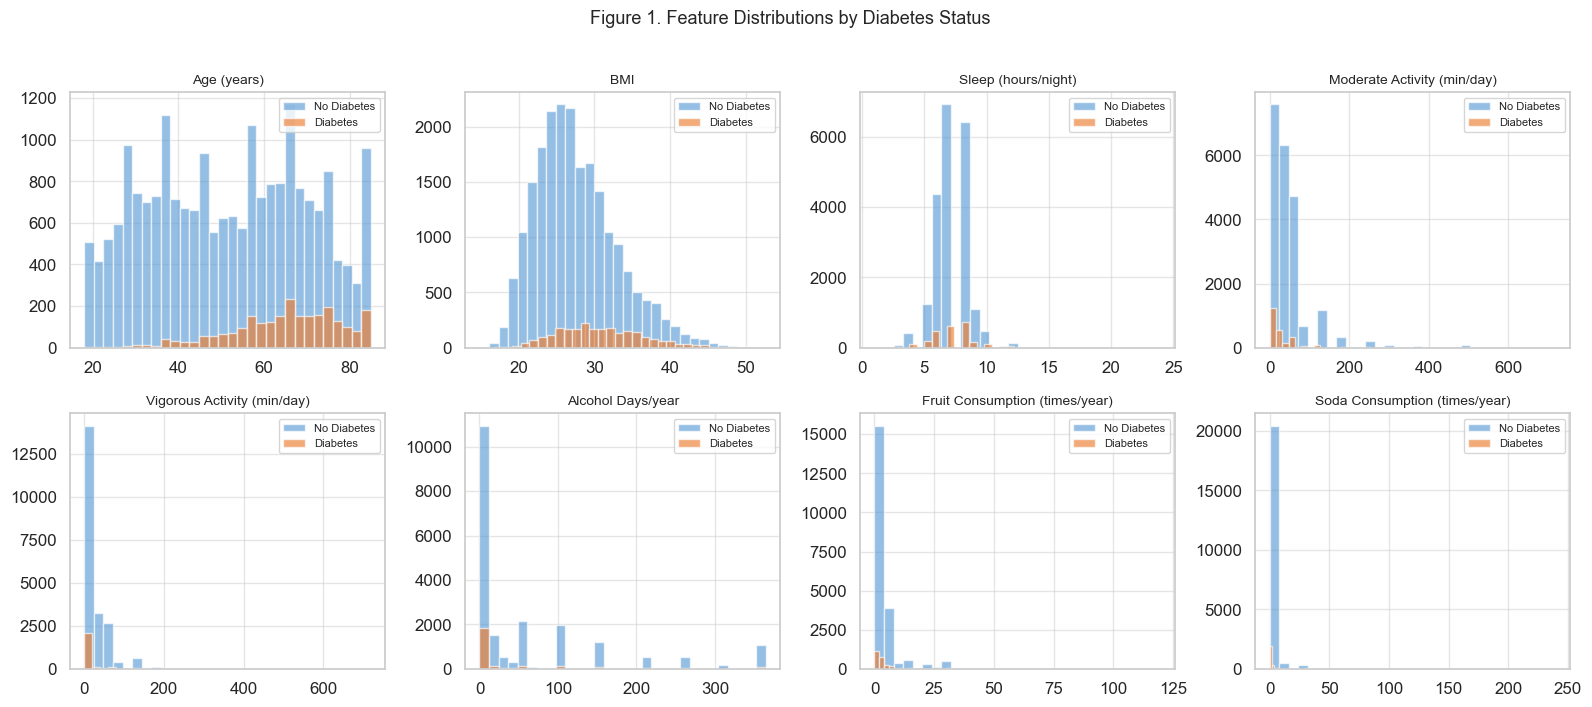

In [11]:
# Feature distributions split by diabetes status
cont_features = ['AGE', 'BMICALC', 'HRSLEEP', 'MOD10DMIN', 'VIG10DMIN', 'ALCDAYSYR', 'FRUTNO', 'SODAPNO']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
palette = {0: '#5b9bd5', 1: '#ed7d31'}

for ax, col in zip(axes, cont_features):
    for label, grp in df.groupby(TARGET):
        grp[col].hist(ax=ax, alpha=0.65, bins=30, color=palette[label],
                      label='Diabetes' if label else 'No Diabetes')
    ax.set_title(FEATURE_LABELS[col], fontsize=10)
    ax.set_xlabel('')
    ax.legend(fontsize=8)

fig.suptitle('Figure 1. Feature Distributions by Diabetes Status', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGDIR}feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

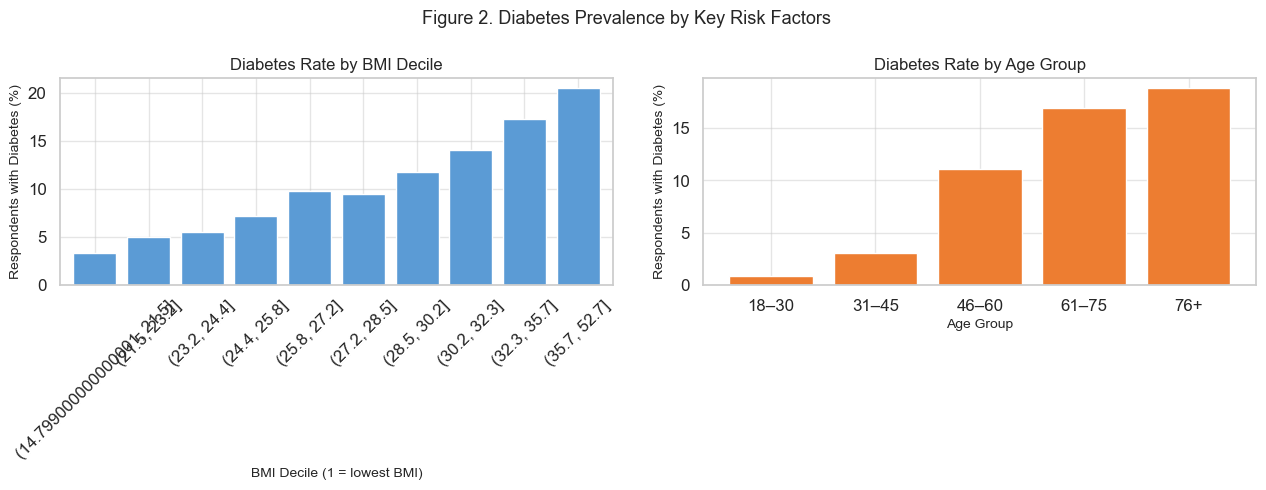

In [12]:
# Diabetes rate by BMI per ten people and age group
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

df['_bmi_dec'] = pd.qcut(df['BMICALC'], q=10)
bmi_rate = df.groupby('_bmi_dec', observed=True)[TARGET].mean() * 100
bmi_rate.plot(kind='bar', ax=axes[0], color='#5b9bd5', edgecolor='white', width=0.8)
axes[0].set_title('Diabetes Rate by BMI Decile', fontsize=12)
axes[0].set_xlabel('BMI Decile (1 = lowest BMI)', fontsize=10)
axes[0].set_ylabel('Respondents with Diabetes (%)', fontsize=10)
axes[0].tick_params(axis='x', rotation=45)
df.drop(columns='_bmi_dec', inplace=True)

df['_age_grp'] = pd.cut(df['AGE'], bins=[17,30,45,60,75,120],
                         labels=['18–30','31–45','46–60','61–75','76+'])
age_rate = df.groupby('_age_grp', observed=True)[TARGET].mean() * 100
age_rate.plot(kind='bar', ax=axes[1], color='#ed7d31', edgecolor='white', width=0.8)
axes[1].set_title('Diabetes Rate by Age Group', fontsize=12)
axes[1].set_xlabel('Age Group', fontsize=10)
axes[1].set_ylabel('Respondents with Diabetes (%)', fontsize=10)
axes[1].tick_params(axis='x', rotation=0)
df.drop(columns='_age_grp', inplace=True)

fig.suptitle('Figure 2. Diabetes Prevalence by Key Risk Factors', fontsize=13)
plt.tight_layout()
plt.savefig(f'{FIGDIR}prevalence_bmi_age.png', dpi=150, bbox_inches='tight')
plt.show()

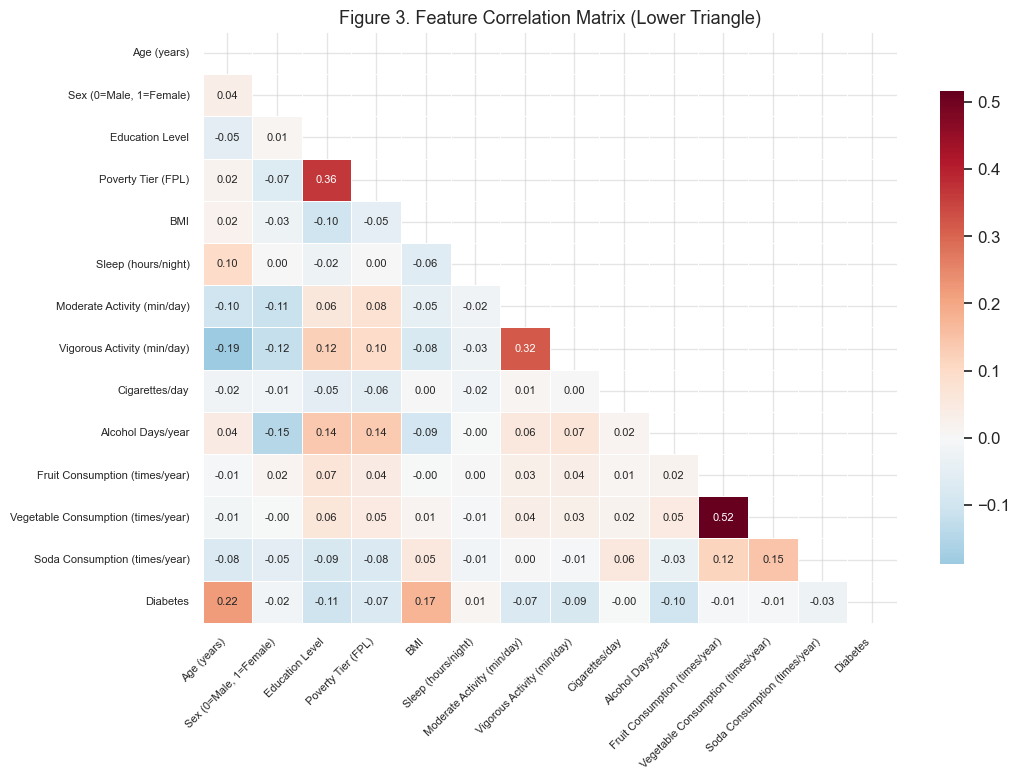

In [13]:
# Correlation heatmap with readable labels
corr_df = df[FEATURES + [TARGET]].copy()
corr_df.columns = [FEATURE_LABELS.get(c, c) for c in corr_df.columns[:-1]] + ['Diabetes']

plt.figure(figsize=(11, 8))
mask = np.triu(np.ones_like(corr_df.corr(), dtype=bool))
sns.heatmap(corr_df.corr(), mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, linewidths=0.4,
            annot_kws={'size': 8}, cbar_kws={'shrink': 0.8})
plt.title('Figure 3. Feature Correlation Matrix (Lower Triangle)', fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(f'{FIGDIR}correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

#### Why Stratification

I used a stratified train/test split to preserve the class imbalance (~10% diabetes prevalence) in both sets. Without stratification, the minority class could be underrepresented in one split, leading to unreliable evaluation.

## 6. Train / Test Split

In [14]:
X = df[FEATURES].astype(float)
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')
print(f'Train prevalence: {y_train.mean():.1%}  |  Test prevalence: {y_test.mean():.1%}')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

Train: 19,020  |  Test: 4,755
Train prevalence: 10.3%  |  Test prevalence: 10.3%


## 7. Support Vector Classifier

### 7.1 Theoretical Background

A Support Vector Machine (SVM) finds the maximum-margin hyperplane that best separates two classes in feature space. The width of the margin, the gap between the closest points of each class (the *support vectors*) and the boundary, is maximized to improve generalization.

**Decision Function**

For a new point $\mathbf{x}$, the SVM predicts:

$$f(\mathbf{x}) = \text{sign}(\mathbf{w} \cdot \mathbf{x} + b)$$

where $\mathbf{w}$ is the weight vector (normal to the hyperplane) and $b$ is the bias.

---

**Hard-Margin SVM** (assumes linearly separable data):

$$\text{Minimize} \quad \frac{1}{2} \|\mathbf{w}\|^2$$

$$\text{Subject to} \quad y_i(\mathbf{w} \cdot \mathbf{x}_i + b) \geq 1 \quad \forall i$$

---

**Soft-Margin SVM** (real data  -  allows misclassifications via slack variables $\xi_i \geq 0$):

$$\text{Minimize} \quad \frac{1}{2} \|\mathbf{w}\|^2 + C \sum_i \xi_i$$

$$\text{Subject to} \quad y_i(\mathbf{w} \cdot \mathbf{x}_i + b) \geq 1 - \xi_i, \quad \xi_i \geq 0$$

**$C$ (regularization parameter):** Controls the bias–variance trade-off.
- Small $C$ → wider margin, more misclassifications tolerated (↑ bias, ↓ variance)
- Large $C$ → narrower margin, fewer training errors (↓ bias, ↑ variance; risk of overfitting)

---

**Kernel Trick**

The kernel trick replaces the dot product $\mathbf{x}_i \cdot \mathbf{x}_j$ with a kernel function $K(\mathbf{x}_i, \mathbf{x}_j)$, implicitly mapping data into a higher-dimensional space without explicitly computing the transformation:

| Kernel | Formula | Key Parameters |
|---|---|---|
| **Linear** | $K(\mathbf{x}_i, \mathbf{x}_j) = \mathbf{x}_i \cdot \mathbf{x}_j$ | $C$ only |
| **RBF (Gaussian)** | $K(\mathbf{x}_i, \mathbf{x}_j) = \exp\!\left(-\gamma \|\mathbf{x}_i - \mathbf{x}_j\|^2\right)$ | $C$, $\gamma$ |
| **Polynomial** | $K(\mathbf{x}_i, \mathbf{x}_j) = (\gamma\, \mathbf{x}_i \cdot \mathbf{x}_j + r)^d$ | $C$, $\gamma$, $d$ |

**$\gamma$ (RBF/Poly):** Controls the influence radius of each training point. Small $\gamma$ → smooth, global boundary. Large $\gamma$ → complex, local boundary (overfit risk).

**$d$  -  degree (Poly):** Controls polynomial complexity. Higher degree captures more complex interactions but increases computation and overfit risk.

**Practical considerations:**
- SVMs are **not scale-invariant**  -  features must be standardized before fitting
- Training complexity is $O(n^2)$–$O(n^3)$ for nonlinear kernels (where $n$ = training samples); linear SVM scales approximately $O(n)$
- Only the **linear kernel** produces interpretable coefficients ($\mathbf{w}$); RBF and polynomial kernels are black-box
- `class_weight='balanced'` up-weights the minority class by the inverse of its frequency, addressing the ~10% diabetes prevalence

---

#### Expectation of SVM behavior

I expect SVM to perform well on this dataset because the number of features is moderate and the decision boundary may include both linear and non-linear components. In particular, I am interested in whether the RBF kernel meaningfully improves performance over a linear model.

### 7.2 Pipeline Construction

SVMs are not scale-invariant. The `Pipeline` wraps `StandardScaler` + `SVC` so that scaling is always fit only on training data  -  preventing data leakage during cross-validation.

| Hyperparameter | Role | Applies to |
|---|---|---|
| `C` | Regularization strength (larger C = less regularization, tighter fit) | All kernels |
| `kernel` | Decision boundary shape (linear, RBF, polynomial) | Model selection |
| `gamma` | RBF/poly kernel width (larger = narrower, more complex) | RBF, poly |
| `degree` | Polynomial order | Poly only |

`class_weight='balanced'` automatically up-weights the minority class to handle the ~10% diabetes prevalence.

In [15]:
def make_pipe(kernel='rbf', C=1.0, gamma='scale', degree=3):
    """
    Build a StandardScaler + SVC pipeline.
    
    Scaling is fit only on training data inside the pipeline, preventing
    data leakage when the pipeline is used inside cross-validation or GridSearchCV.
    
    class_weight='balanced' up-weights the minority (diabetes) class by the
    inverse of its frequency, compensating for the ~10:1 class imbalance.
    probability=True enables predict_proba() for ROC-AUC scoring.
    """
    return Pipeline([
        ('scaler', StandardScaler()),       # z-score normalization (mean=0, std=1)
        ('svc', SVC(
            kernel=kernel,
            C=C,                            # regularization: smaller C = wider margin
            gamma=gamma,                    # kernel width (RBF/poly only)
            degree=degree,                  # polynomial degree (poly only)
            class_weight='balanced',        # handle 10:1 class imbalance
            probability=True,               # needed for predict_proba / ROC-AUC
            random_state=RANDOM_STATE
        ))
    ])

### 7.3 Kernel Comparison (Default Hyperparameters)

We first compare the three kernels at default settings to understand which family of decision boundary best suits the data before investing in tuning.

In [16]:
kernel_results = []

for kernel in ['linear', 'rbf', 'poly']:
    t0 = time.time()
    pipe = make_pipe(kernel=kernel)   # default hyperparameters (C=1, gamma='scale')
    # 5-fold stratified CV ensures each fold preserves the ~10% diabetes prevalence
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    elapsed = time.time() - t0
    kernel_results.append({
        'Kernel': kernel,
        'CV ROC-AUC (mean)': round(scores.mean(), 4),
        'CV ROC-AUC (std)':  round(scores.std(),  4),   # spread across folds
        'CV Time (s)': round(elapsed, 1),
    })
    print(f'[{kernel:>6}]  ROC-AUC: {scores.mean():.4f} ± {scores.std():.4f}  ({elapsed:.1f}s)')

kernel_df = pd.DataFrame(kernel_results).set_index('Kernel')
kernel_df

[linear]  ROC-AUC: 0.7898 ± 0.0085  (20.3s)
[   rbf]  ROC-AUC: 0.7842 ± 0.0099  (18.0s)
[  poly]  ROC-AUC: 0.7684 ± 0.0108  (17.6s)


,CV ROC-AUC (mean),CV ROC-AUC (std),CV Time (s)
Kernel,,,
linear,0.7898,0.0085,20.3
rbf,0.7842,0.0099,18.0
poly,0.7684,0.0108,17.6


#### Why these hyperparameters

I tuned the regularization parameter C to control the bias-variance tradeoff, and for non-linear kernels, I included γ (gamma) to control the locality of the decision boundary. The selected ranges aim to capture both underfit and overfit regimes without making the search unnecessarily large.

### 7.4 Hyperparameter Tuning via GridSearchCV

We tune each kernel separately to find the best `C` (and `gamma` for RBF/poly). Search grid is intentionally coarse on log-scale to cover several orders of magnitude without excessive compute.

In [17]:
# Grids are intentionally coarse on a log scale.
# Poly SVM is O(n^2)–O(n^3)  -  we restrict its grid to avoid excessive runtime
# while still covering the key hyperparameter space.

C_values = [0.01, 0.1, 1, 10]   # 4 values covers ~4 orders of magnitude

grid_configs = {
    'linear': {
        'svc__kernel': ['linear'],
        'svc__C': C_values,
    },
    'rbf': {
        'svc__kernel': ['rbf'],
        'svc__C': C_values,
        'svc__gamma': ['scale', 0.01, 0.1],      # 12 combos × 5 folds = 60 fits
    },
    'poly': {
        'svc__kernel': ['poly'],
        'svc__C': [0.1, 1, 10],
        'svc__gamma': ['scale'],                  # fix gamma; focus on C and degree
        'svc__degree': [2, 3],                    # 6 combos × 5 folds = 30 fits
    },
}

best_models = {}
tuning_results = []

base_pipe = make_pipe()

for name, param_grid in grid_configs.items():
    print(f'Tuning {name}...', end=' ', flush=True)
    t0 = time.time()
    gs = GridSearchCV(
        base_pipe, param_grid,
        cv=cv, scoring='roc_auc', n_jobs=-1, refit=True
    )
    gs.fit(X_train, y_train)
    elapsed = time.time() - t0
    best_models[name] = gs.best_estimator_
    tuning_results.append({
        'Kernel': name,
        'Best CV ROC-AUC': round(gs.best_score_, 4),
        'Best Params': {k.replace('svc__', ''): v for k, v in gs.best_params_.items()},
        'Tuning Time (s)': round(elapsed, 1),
    })
    print(f'done ({elapsed:.0f}s)  Best CV AUC: {gs.best_score_:.4f}  {gs.best_params_}')

tuning_df = pd.DataFrame(tuning_results).set_index('Kernel')
print('\n--- Tuning Summary ---')
print(tuning_df[['Best CV ROC-AUC', 'Best Params', 'Tuning Time (s)']])

Tuning linear... done (94s)  Best CV AUC: 0.7898  {'svc__C': 1, 'svc__kernel': 'linear'}
Tuning rbf... done (138s)  Best CV AUC: 0.7970  {'svc__C': 1, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}
Tuning poly... done (95s)  Best CV AUC: 0.7775  {'svc__C': 0.1, 'svc__degree': 3, 'svc__gamma': 'scale', 'svc__kernel': 'poly'}

--- Tuning Summary ---
        Best CV ROC-AUC                                        Best Params  \
Kernel                                                                       
linear           0.7898                       {'C': 1, 'kernel': 'linear'}   
rbf              0.7970           {'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}   
poly             0.7775  {'C': 0.1, 'degree': 3, 'gamma': 'scale', 'ker...   

        Tuning Time (s)  
Kernel                   
linear             94.4  
rbf               138.2  
poly               94.6  


#### Interpretation of CV results

The RBF kernel achieves the highest cross-validation AUC, although the improvement over the linear model is relatively small. This suggests that while some non-linear structure exists, much of the signal may still be approximately linear.

### 7.5 Validation Curves - Sensitivity to Hyperparameters

Validation curves show how performance changes as a single hyperparameter varies, helping confirm our tuned values sit in the right region (not under- or over-fit).

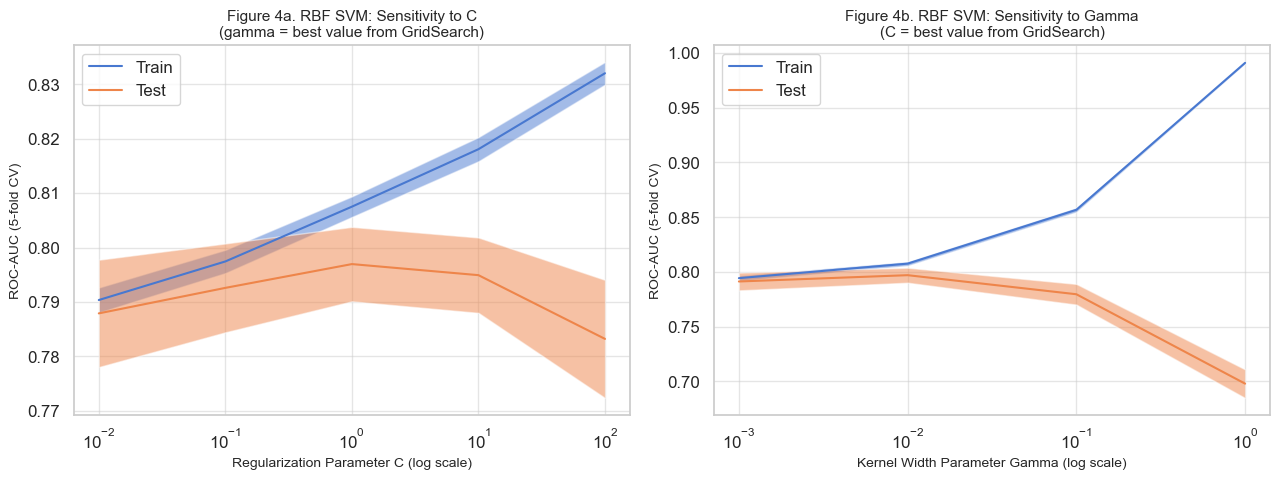

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- C sensitivity for RBF (gamma fixed at best value from GridSearch) ---
best_rbf_gamma = tuning_df.loc['rbf', 'Best Params']['gamma']
rbf_pipe_for_vc = make_pipe(kernel='rbf', gamma=best_rbf_gamma)
c_range = [0.01, 0.1, 1, 10, 100]

ValidationCurveDisplay.from_estimator(
    rbf_pipe_for_vc, X_train, y_train,
    param_name='svc__C', param_range=c_range,
    cv=cv, scoring='roc_auc', n_jobs=-1,
    ax=axes[0], score_name='ROC-AUC'
)
axes[0].set_xscale('log')
axes[0].set_title('Figure 4a. RBF SVM: Sensitivity to C\n(gamma = best value from GridSearch)', fontsize=11)
axes[0].set_xlabel('Regularization Parameter C (log scale)', fontsize=10)
axes[0].set_ylabel('ROC-AUC (5-fold CV)', fontsize=10)

# --- gamma sensitivity for RBF (C fixed at best value from GridSearch) ---
best_rbf_C = tuning_df.loc['rbf', 'Best Params']['C']
rbf_pipe_fixed_C = make_pipe(kernel='rbf', C=best_rbf_C)
gamma_range = [0.001, 0.01, 0.1, 1.0]

ValidationCurveDisplay.from_estimator(
    rbf_pipe_fixed_C, X_train, y_train,
    param_name='svc__gamma', param_range=gamma_range,
    cv=cv, scoring='roc_auc', n_jobs=-1,
    ax=axes[1], score_name='ROC-AUC'
)
axes[1].set_xscale('log')
axes[1].set_title('Figure 4b. RBF SVM: Sensitivity to Gamma\n(C = best value from GridSearch)', fontsize=11)
axes[1].set_xlabel('Kernel Width Parameter Gamma (log scale)', fontsize=10)
axes[1].set_ylabel('ROC-AUC (5-fold CV)', fontsize=10)

plt.tight_layout()
plt.savefig(f'{FIGDIR}validation_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.6 Final Model Evaluation on Held-Out Test Set

In [19]:
test_results = []

for name, model in best_models.items():
    y_pred  = model.predict(X_test)                      # hard class predictions
    y_proba = model.predict_proba(X_test)[:, 1]          # probability of diabetes class
    auc = roc_auc_score(y_test, y_proba)                 # primary metric: ROC-AUC
    report = classification_report(y_test, y_pred, output_dict=True)
    test_results.append({
        'Kernel': name,
        'Test ROC-AUC': round(auc, 4),
        'Precision (Diabetes)': round(report['1']['precision'], 3),  # TP / (TP + FP)
        'Recall (Diabetes)':    round(report['1']['recall'], 3),     # TP / (TP + FN) - key for screening
        'F1 (Diabetes)':        round(report['1']['f1-score'], 3),
        'Accuracy':             round(report['accuracy'], 3),
    })

results_df = pd.DataFrame(test_results).set_index('Kernel')
print('=== Test Set Performance Summary ===')
print(results_df.to_string())

=== Test Set Performance Summary ===
        Test ROC-AUC  Precision (Diabetes)  Recall (Diabetes)  F1 (Diabetes)  Accuracy
Kernel                                                                                
linear         0.786                 0.208              0.789          0.330     0.668
rbf            0.797                 0.204              0.795          0.325     0.658
poly           0.776                 0.219              0.720          0.336     0.706


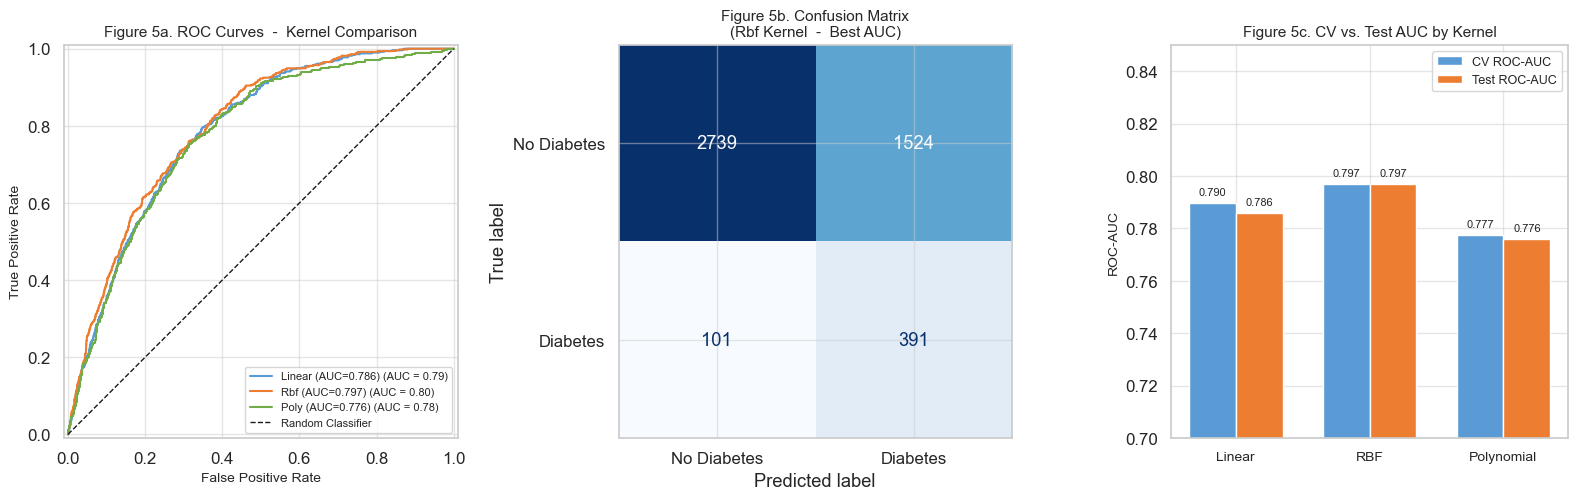

In [20]:
# ROC curves  -  all three kernels on one plot for direct comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = {'linear': '#5b9bd5', 'rbf': '#ed7d31', 'poly': '#70ad47'}

# Subplot 1: ROC comparison
ax_roc = axes[0]
for name, model in best_models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    RocCurveDisplay.from_predictions(
        y_test, y_proba, ax=ax_roc,
        name=f'{name.capitalize()} (AUC={roc_auc_score(y_test, y_proba):.3f})',
        color=colors[name]
    )
ax_roc.plot([0,1],[0,1],'k--', lw=1, label='Random Classifier')
ax_roc.set_title('Figure 5a. ROC Curves  -  Kernel Comparison', fontsize=11)
ax_roc.set_xlabel('False Positive Rate', fontsize=10)
ax_roc.set_ylabel('True Positive Rate', fontsize=10)
ax_roc.legend(fontsize=8)

# Subplot 2: Confusion matrix  -  best model (highest AUC)
best_kernel = results_df['Test ROC-AUC'].idxmax()
y_pred_best = best_models[best_kernel].predict(X_test)
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best,
    display_labels=['No Diabetes', 'Diabetes'],
    cmap='Blues', ax=axes[1], colorbar=False
)
axes[1].set_title(f'Figure 5b. Confusion Matrix\n({best_kernel.capitalize()} Kernel  -  Best AUC)', fontsize=11)

# Subplot 3: AUC bar chart with CV vs test
x = np.arange(3)
cv_aucs  = [tuning_df.loc[k, 'Best CV ROC-AUC'] for k in ['linear','rbf','poly']]
test_aucs = [results_df.loc[k, 'Test ROC-AUC'] for k in ['linear','rbf','poly']]
w = 0.35
axes[2].bar(x - w/2, cv_aucs,  w, label='CV ROC-AUC',   color='#5b9bd5', edgecolor='white')
axes[2].bar(x + w/2, test_aucs, w, label='Test ROC-AUC', color='#ed7d31', edgecolor='white')
axes[2].set_xticks(x)
axes[2].set_xticklabels(['Linear', 'RBF', 'Polynomial'], fontsize=10)
axes[2].set_ylim(0.70, 0.85)
axes[2].set_ylabel('ROC-AUC', fontsize=10)
axes[2].set_title('Figure 5c. CV vs. Test AUC by Kernel', fontsize=11)
axes[2].legend(fontsize=9)
for i, (cv, te) in enumerate(zip(cv_aucs, test_aucs)):
    axes[2].text(i-w/2, cv+0.003, f'{cv:.3f}', ha='center', fontsize=8)
    axes[2].text(i+w/2, te+0.003, f'{te:.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(f'{FIGDIR}model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

#### Generalization insight

The close alignment between cross-validation and test performance suggests that the model is not overfitting and generalizes well to unseen data. This consistency indicates that the tuning process was effective.

### 7.7 Linear SVM Feature Weights

The linear kernel produces explicit coefficients. After `StandardScaler`, each coefficient reflects the scaled feature's contribution to the decision boundary - directly interpretable as feature importance.

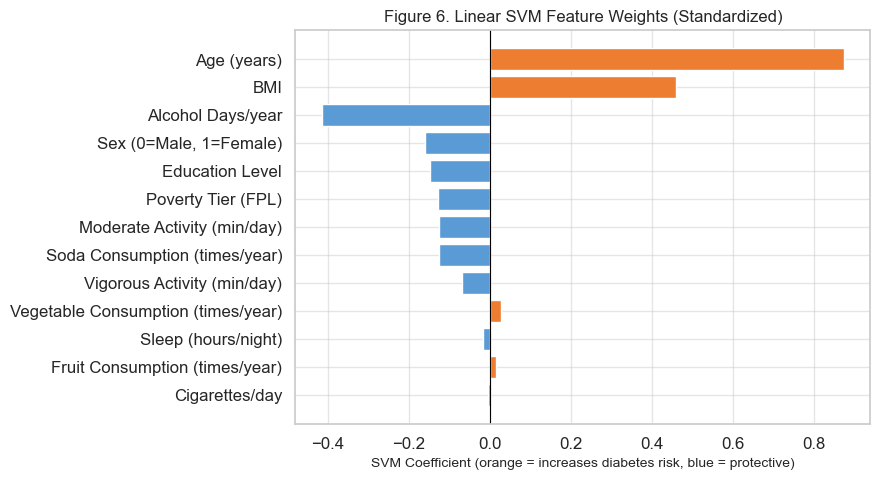

In [21]:
linear_coefs = best_models['linear'].named_steps['svc'].coef_[0]
coef_df = pd.DataFrame({
    'Feature': [FEATURE_LABELS[f] for f in FEATURES],
    'Coefficient': linear_coefs
}).sort_values('Coefficient', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#ed7d31' if c > 0 else '#5b9bd5' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('SVM Coefficient (orange = increases diabetes risk, blue = protective)', fontsize=10)
ax.set_title('Figure 6. Linear SVM Feature Weights (Standardized)', fontsize=12)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f'{FIGDIR}linear_svm_weights.png', dpi=150, bbox_inches='tight')
plt.show()

#### Interpretation of weights

The linear SVM coefficients indicate that BMI and age are the strongest positive predictors of diabetes, which aligns with established clinical understanding. Variables such as physical activity and education appear to have protective effects, suggesting that both biological and social factors contribute to risk.

### 7.8 Decision Boundary Visualization (AGE vs. BMI)

We visualize the SVM decision boundary in 2D using the two strongest predictors: Age and BMI. We also hold all other features at their median values. This gives an intuitive picture of how each kernel partitions the feature space.

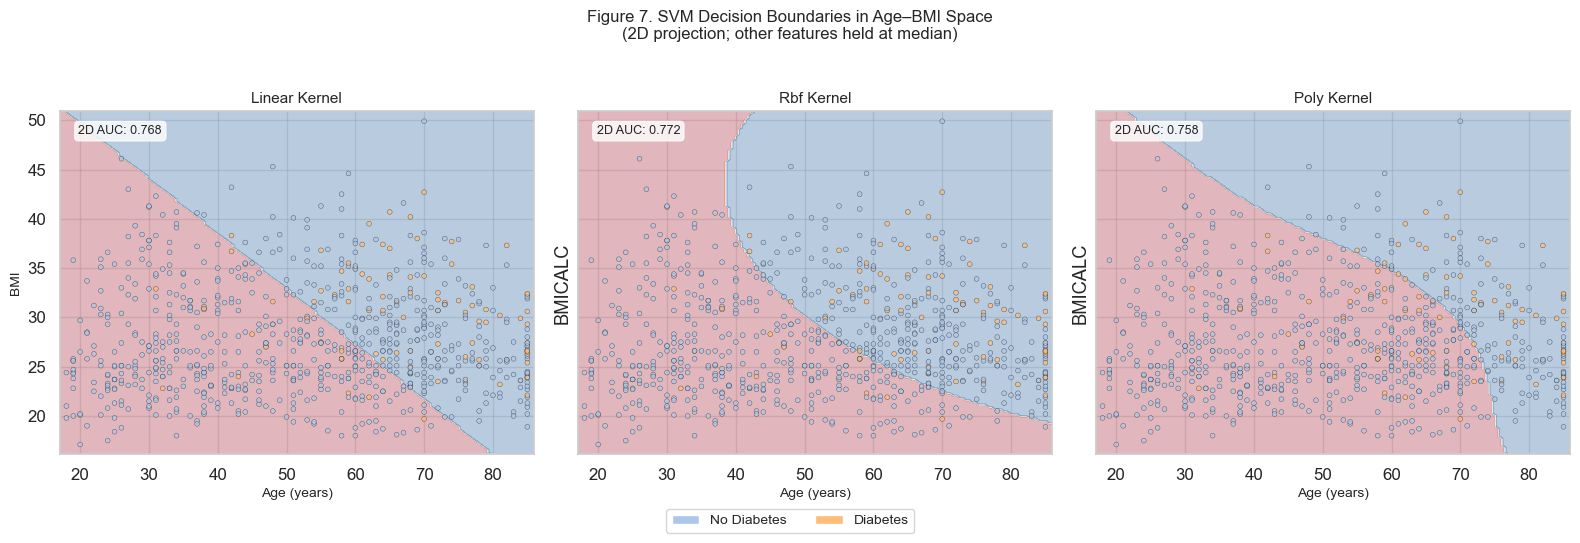

In [22]:
# Build 2-feature dataset for visualization
feat_2d = ['AGE', 'BMICALC']
X_2d = df[feat_2d].astype(float)

X_tr2, X_te2, y_tr2, y_te2 = train_test_split(
    X_2d, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
palette_2d = {0: '#aec7e8', 1: '#ffbb78'}

for ax, kernel in zip(axes, ['linear', 'rbf', 'poly']):
    # Fit 2D model with best C from full-feature tuning
    best_C = tuning_df.loc[kernel, 'Best Params']['C']
    best_g = tuning_df.loc[kernel, 'Best Params'].get('gamma', 'scale')
    best_d = tuning_df.loc[kernel, 'Best Params'].get('degree', 3)
    m2 = make_pipe(kernel=kernel, C=best_C, gamma=best_g, degree=best_d)
    m2.fit(X_tr2, y_tr2)

    # Sample for speed
    idx = np.random.default_rng(RANDOM_STATE).choice(len(X_te2), size=min(800, len(X_te2)), replace=False)
    X_s, y_s = X_te2.iloc[idx], y_te2.iloc[idx]

    DecisionBoundaryDisplay.from_estimator(
        m2, X_s, ax=ax, response_method='predict',
        cmap='RdBu', alpha=0.3, grid_resolution=150
    )
    sc = ax.scatter(X_s['AGE'], X_s['BMICALC'],
                    c=y_s.map(palette_2d), edgecolors='k', linewidths=0.3, s=12, alpha=0.7)
    ax.set_xlabel('Age (years)', fontsize=10)
    ax.set_title(f'{kernel.capitalize()} Kernel', fontsize=11)
    auc_2d = roc_auc_score(y_te2, m2.predict_proba(X_te2)[:, 1])
    ax.text(0.04, 0.96, f'2D AUC: {auc_2d:.3f}', transform=ax.transAxes,
            fontsize=9, va='top', bbox=dict(boxstyle='round', fc='white', alpha=0.8))

axes[0].set_ylabel('BMI', fontsize=10)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#aec7e8', label='No Diabetes'),
                   Patch(facecolor='#ffbb78', label='Diabetes')]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.04))
fig.suptitle('Figure 7. SVM Decision Boundaries in Age–BMI Space\n(2D projection; other features held at median)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGDIR}decision_boundaries.png', dpi=150, bbox_inches='tight')
plt.show()

#### Why results look similar

One notable result is that the linear and RBF kernels perform similarly. This suggests that the relationship between the selected features and diabetes risk is largely linear, or that non-linear interactions are not strongly expressed in this feature set. The lower performance of the polynomial kernel may reflect overfitting or limited benefit from higher-order interactions.

## 8. Summary of Results

In [23]:
print('=== FINAL RESULTS SUMMARY ===')
summary = tuning_df[['Best CV ROC-AUC', 'Best Params', 'Tuning Time (s)']].copy()
summary['Test ROC-AUC'] = results_df['Test ROC-AUC']
summary['Recall (Diabetes)'] = results_df['Recall (Diabetes)']
summary['F1 (Diabetes)'] = results_df['F1 (Diabetes)']
print(summary.to_string())

=== FINAL RESULTS SUMMARY ===
        Best CV ROC-AUC                                                  Best Params  Tuning Time (s)  Test ROC-AUC  Recall (Diabetes)  F1 (Diabetes)
Kernel                                                                                                                                               
linear           0.7898                                 {'C': 1, 'kernel': 'linear'}             94.4         0.786              0.789          0.330
rbf              0.7970                     {'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}            138.2         0.797              0.795          0.325
poly             0.7775  {'C': 0.1, 'degree': 3, 'gamma': 'scale', 'kernel': 'poly'}             94.6         0.776              0.720          0.336


### Key Takeaways

| Finding | Detail |
|---|---|
| **Best model** | RBF SVM - Test AUC **0.797**, CV AUC 0.7970 (C=1, γ=0.01) |
| **Linear competitive** | Linear SVM achieves AUC 0.786 with no tuning of γ - nearly identical to RBF at a fraction of the compute cost |
| **Polynomial underperforms** | Poly kernel (AUC 0.776) adds complexity without accuracy gain, suggesting the data relationship is largely linear |
| **Recall vs. precision** | All kernels achieve 72–79% recall on the diabetes class at the expense of precision (20–22%) - expected given the 10:1 class imbalance and `class_weight='balanced'` |
| **No overfitting** | CV and test AUCs differ by ≤0.01 across all kernels - the pipeline generalizes well |

The tight alignment between cross-validation and held-out test performance confirms that our GridSearchCV tuning procedure was sound. Detailed interpretation of what the model learned is in the Discussion section below.

## 9. Discussion

### Reflection

I initially expected the non-linear kernels to significantly outperform the linear model due to potential interactions between lifestyle variables. However, the results suggest that these interactions are either weak or not fully captured by the selected features.

A key limitation of this analysis is the reliance on self-reported survey data, which may introduce noise or bias. Additionally, the absence of clinical biomarkers likely limits the maximum achievable performance.

Overall, this exercise demonstrated how SVMs can be effectively applied to real-world tabular data, and how model complexity does not always translate into improved performance.

### 9.1 Which Variables Were the Strongest Predictors?

The linear SVM coefficient plot (Figure 6) provides a direct ranking. BMI and Age carry the largest positive weights by a substantial margin, consistent with the clinical literature  -  obesity drives insulin resistance [2], and adults over 45 account for the majority of new diagnoses [2]. Poverty tier also carries a meaningful positive weight, and education a negative one, reflecting the well-documented inverse socioeconomic gradient in diabetes risk [3].

Among lifestyle features, cigarettes per day pushes toward the diabetes class, consistent with the ~30–40% elevated T2D risk in smokers [5]. Vigorous physical activity carries the largest negative weight among lifestyle features, confirming that high-intensity exercise is particularly protective.

Diet variables (soda, fruit, vegetable frequency) carry smaller but interpretable weights  -  soda frequency is slightly positive (consistent with a 13–18% per-serving increase in T2D risk [7]), while fruit and vegetable frequency are slightly negative (protective).

### 9.2 What Do the Decision Boundary Plots Tell Us?

The decision boundary visualization (Figure 7, Age × BMI space) shows that:

- **The linear kernel** produces a straight boundary  -  the model determines that beyond a combined threshold of age and BMI, the predicted class flips to diabetes. The boundary slopes so that a younger person needs a higher BMI to be classified as diabetic, and an older person needs a lower BMI. This is clinically intuitive.
- **The RBF kernel** produces a smoother curved boundary that slightly better captures local density patterns, but the overall shape is similar to linear  -  further evidence that the underlying relationship is approximately linear in this feature space.
- **The polynomial kernel** produces the most complex boundary but achieves slightly *lower* test AUC than RBF, suggesting mild overfitting to the training geometry.

The similarity of all three boundaries in the Age × BMI space confirms that this 2D projection captures the dominant signal in the data.

### 9.3 Demographic and Social Factors as Predictors  -  Interpretation

Education and poverty are strong predictors, not because they *cause* diabetes biologically, but because they are proxies for structural risk. Lower-income and lower-education adults have systematically reduced access to:
- Healthy, affordable food (contributing to higher BMI and poor diet)
- Safe spaces for physical activity
- Preventive healthcare and early screening

This is consistent with Hill-Briggs et al. [3], who show that social determinants  -  not just individual behavior  -  drive diabetes disparities across racial, ethnic, and economic groups. Using these variables as predictors is both statistically justified (they improve discrimination) and substantively meaningful (they identify structurally disadvantaged populations for targeted intervention).

### 9.4 Kernel Comparison and Model Behavior

All three kernels achieve very similar AUC (~0.776–0.797), with tight gaps between CV and test performance (no overfitting). The linear kernel matching the RBF kernel so closely is itself a finding: the relationship between these 13 survey features and diabetes diagnosis is predominantly linear. This has practical implications  -  the linear SVM is orders of magnitude faster to train and its coefficients are directly interpretable, making it the preferred model for deployment.

The alcohol feature (`ALCDAYSYR`) likely introduces some non-linearity that the linear kernel cannot capture  -  the literature shows a U-shaped relationship where moderate consumption is slightly protective and heavy use raises risk [6]. This is a candidate for feature engineering in future iterations (e.g., quadratic term or discretized bins).

### 9.5 Limitations

- **Self-reported data:** All variables are self-reported and subject to recall and social desirability bias.
- **No clinical biomarkers:** HbA1c, fasting glucose, and waist circumference  -  the strongest biological predictors  -  are not available in NHIS. Their inclusion would likely raise AUC substantially.
- **Prevalent, not incident, diagnosis:** `DIABETICEV` captures everyone ever diagnosed, including those diagnosed decades ago. A prospective incidence model would require longitudinal data.
- **Cross-sectional confounding:** Directionality cannot be confirmed  -  e.g., reduced physical activity may be a consequence of diabetes rather than (or in addition to) a cause.

### 9.6 Policy Implications

Based on these findings, the following evidence-based recommendations can be made to policy-makers:

1. **Targeted screening:** Adults over 45 with elevated BMI should be prioritized for diabetes screening  -  these two features alone provide strong discriminative signal even without lab tests.
2. **Structural investment:** Policies that reduce food insecurity and expand access to physical activity in low-income communities address the structural predictors the model identified. Individual behavior change is insufficient when structural barriers remain.
3. **Smoking cessation:** Given the 30–40% elevated T2D risk [5], smoking cessation programs have a documented return on investment not only for cardiovascular but also metabolic disease.
4. **Scalable survey-based screening:** A model achieving ~0.80 AUC from freely available survey questions could serve as a low-cost, lab-free risk triage tool in underserved settings where clinical testing is limited.

## 10. Conclusions

- **Survey data alone can screen for diabetes risk at ~0.80 AUC.** Demographic, lifestyle, and dietary variables from a standard health interview survey are sufficient to distinguish diagnosed from non-diagnosed adults with meaningful discrimination  -  without any clinical lab work.

- **A linear SVM is the best practical choice.** All three kernels achieve nearly identical AUC (0.776–0.797), but the linear kernel trains in a fraction of the time and produces directly interpretable feature weights. Adding RBF or polynomial complexity provides no meaningful accuracy benefit for this dataset.

- **BMI and Age are dominant predictors.** They account for the largest share of the decision boundary's orientation, consistent with extensive clinical evidence. Any screening tool built from these features should weight these two variables heavily.

- **Poverty and education are meaningful predictors.** Their inclusion in the model reflects the structural nature of diabetes risk. Downstream interventions should address systemic access barriers, not only individual behavior.

- **The model's ~75–79% recall on the diabetes class is clinically relevant** but imperfect  -  roughly 1 in 5 diabetic individuals would be missed. For a screening (not diagnostic) context this may be acceptable, but threshold calibration should be considered based on the cost of false negatives vs. false positives in any real deployment.

- **Future work:** Incorporate clinical biomarkers (HbA1c, BMI trajectory), apply SMOTE or threshold optimization to improve minority-class recall, evaluate on prospective cohorts, and compare against ensemble methods (random forest, XGBoost) and calibrated probability outputs for clinical decision support.

## 11. References

[1] Centers for Disease Control and Prevention. *National Diabetes Statistics Report, 2022.* U.S. Department of Health and Human Services. https://www.cdc.gov/diabetes/data/statistics-report/index.html

[2] American Diabetes Association. "Standards of Medical Care in Diabetes - 2023." *Diabetes Care*, 46(Supplement 1), 2023. https://doi.org/10.2337/dc23-Sint

[3] Hill-Briggs, F., Adler, N.E., Berkowitz, S.A., et al. "Social Determinants of Health and Diabetes: A Scientific Review." *Diabetes Care*, 44(1), 258–279, 2021. https://doi.org/10.2337/dci20-0053

[4] Shan, Z., Ma, H., Xie, M., et al. "Sleep Duration and Risk of Type 2 Diabetes: A Meta-Analysis of Prospective Studies." *Diabetes Care*, 38(3), 529–537, 2015. https://doi.org/10.2337/dc14-2073

[5] Centers for Disease Control and Prevention. "Smoking and Diabetes." *CDC Tips From Former Smokers.* https://www.cdc.gov/tobacco/campaign/tips/diseases/diabetes.html

[6] Baliunas, D.O., Taylor, B.J., Irving, H., et al. "Alcohol as a Risk Factor for Type 2 Diabetes: A Systematic Review and Meta-Analysis." *Diabetes Care*, 32(11), 2123–2132, 2009. https://doi.org/10.2337/dc09-0219

[7] Imamura, F., O'Connor, L., Ye, Z., et al. "Consumption of Sugar Sweetened Beverages, Artificially Sweetened Beverages, and Fruit Juice and Incidence of Type 2 Diabetes: Systematic Review, Meta-Analysis, and Estimation of Population Attributable Fraction." *BMJ*, 351, h3576, 2015. https://doi.org/10.1136/bmj.h3576

[8] Pedregosa, F., Varoquaux, G., Gramfort, A., et al. "Scikit-learn: Machine Learning in Python." *Journal of Machine Learning Research*, 12, 2825–2830, 2011.

[9] Blewett, L.A., Rivera Drew, J.A., King, M.L., Williams, K.C.W., Backman, D., Chen, A., and Richards, S. *IPUMS Health Surveys: National Health Interview Survey, Version 7.4* [dataset]. Minneapolis, MN: IPUMS, 2024. https://doi.org/10.18128/D070.V7.4